# 🧠 Phase 3: Text-to-Speech (TTS) Integration
## Real-Time Image Captioning for Visually Impaired

In this phase, we will:
1. Turn the model's text output into **audible speech**.
2. We'll use `pyttsx3`, which works **completely offline** and in real-time, matching the goal of creating an accessible tool for the visually impaired.

## ✅ Step 1: Install & Import TTS Libraries

In [3]:
!pip install pyttsx3 pypiwin32 gTTS IPython

## ✅ Step 2: Load Model and Setup TTS Engine

In [1]:
import os
import json
import pickle
import pyttsx3
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

# 1. Setup TTS Engine (Offline, Real-time)
engine = pyttsx3.init()
# Optional: slow down the speech slightly for better clarity
engine.setProperty('rate', 150) 
voices = engine.getProperty('voices')
# Try to pick a female voice if available, usually clearer
for voice in voices:
    if "female" in voice.name.lower() or "zira" in voice.name.lower():
        engine.setProperty('voice', voice.id)
        break

def speak(text):
    print(f"\U0001f50a Speaking: \"{text}\"")
    engine.say(text)
    engine.runAndWait()

# 2. Setup Device & Config
OUTPUT_DIR = r"C:\btech\model_output_pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\u2705 Device: {device}")

with open(os.path.join(OUTPUT_DIR, 'config.json'), 'r') as f:
    config = json.load(f)

class Vocabulary:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.word2idx = {}
        self.idx2word = {}
        self.idx = 0
    def __call__(self, word):
        if word not in self.word2idx: return self.word2idx['<unk>']
        return self.word2idx[word]
    def __len__(self): return len(self.word2idx)

with open(os.path.join(OUTPUT_DIR, 'vocab.pkl'), 'rb') as f:
    vocab = pickle.load(f)

# 3. Load ResNet50 (Encoder)
resnet = models.resnet50(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval()

transform = transforms.Compose([
    transforms.Resize((config['IMG_SIZE'], config['IMG_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Load Decoder (RNN)
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha

class DecoderRNN(nn.Module):
    def __init__(self, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, attention_dim=256, drop_prob=0.5):
        super(DecoderRNN, self).__init__()
        self.vocab_size = vocab_size
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(p=drop_prob)
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

decoder = DecoderRNN(
    embed_dim=config['EMBED_DIM'], 
    decoder_dim=config['HIDDEN_DIM'], 
    vocab_size=config['VOCAB_SIZE'], 
    attention_dim=config['ATTENTION_DIM']
).to(device)

decoder.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'), map_location=device))
decoder.eval()
print("\u2705 Models loaded and ready!")

✅ Device: cuda
✅ Models loaded and ready!


## ✅ Step 3: Full Inference Pipeline (Image → CNN → RNN → TTS)

In [2]:
def generate_caption_greedy_from_image(img_path, resnet, decoder, vocab, max_len=35):
    # 1. Load and preprocess image
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # 2. Extract features using ResNet50
    with torch.no_grad():
        features = resnet(img_tensor).squeeze(-1).squeeze(-1) # (1, 2048)
        
        # 3. Generate caption using DecoderRNN
        h, c = decoder.init_hidden_state(features.unsqueeze(1))
        word = torch.tensor([vocab.word2idx['<start>']]).to(device)
        caption = []
        
        for i in range(max_len):
            embeddings = decoder.embedding(word).unsqueeze(1)
            attention_weighted_encoding, _ = decoder.attention(features.unsqueeze(1), h)
            gate = decoder.sigmoid(decoder.f_beta(h))
            attention_weighted_encoding = gate * attention_weighted_encoding
            
            h, c = decoder.decode_step(
                torch.cat([embeddings.squeeze(1), attention_weighted_encoding], dim=1),
                (h, c)
            )
            
            preds = decoder.fc(h)
            predicted_idx = preds.argmax(dim=1).item()
            
            if predicted_idx == vocab.word2idx['<end>']:
                break
                
            caption.append(vocab.idx2word[predicted_idx])
            word = torch.tensor([predicted_idx]).to(device)
            
    return ' '.join(caption)

def run_tts_pipeline(img_path):
    print("Processing image...")
    
    # Show image
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    # Generate Text
    caption = generate_caption_greedy_from_image(img_path, resnet, decoder, vocab)
    
    # Speak Text
    speak(caption)

## ✅ Step 4: Test it out!
Let's grab a random image from the dataset and listen to the result!

Processing image...


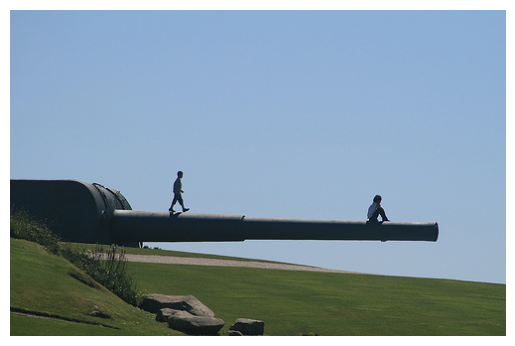

🔊 Speaking: "a man is sitting on a bench"


In [4]:
import os
import random

DATASET_PATH = r"C:\btech\archive"
IMAGES_DIR = os.path.join(DATASET_PATH, "Images")

# Get a random image from the folder
all_images = os.listdir(IMAGES_DIR)
random_image = random.choice(all_images)
test_image_path = os.path.join(IMAGES_DIR, random_image)

# Run the pipeline! Ensure your speakers are ON!
run_tts_pipeline(test_image_path)